# Contexto del Dataset

<!--
Alguna explicación del dataset. Lo que aqui se escriba se amplica en el reporte pero queda casi integro en la presentación

# Diccionario de Datos
   
Nota: las siglas _"rnped"_ y _"rnpedno"_ significan _"Red Nacional de Personas Desaparecidas"_ y _"Red Nacional de Personas Desaparecidas No Localizadas."_

In [2]:
from __future__ import annotations
from typing import Dict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset_path = "tot_reg_desap.csv"


def infer_statistical_type(series: pd.Series) -> str:
    """
    Clasifica el tipo estadístico de una variable:
    - numérico
    - categórico
    """
    if pd.api.types.is_numeric_dtype(series):
        return "numérico"
    return "categórico"


def infer_semantic_type(series: pd.Series, col_name: str) -> str:
    """
    Regresa una etiqueta de tipo de dato más legible para reporte.
    """
    if pd.api.types.is_integer_dtype(series):
        return "entero"
    if pd.api.types.is_float_dtype(series):
        return "flotante"
    if pd.api.types.is_bool_dtype(series):
        return "booleano"
    if pd.api.types.is_datetime64_any_dtype(series):
        return "fecha/hora"

    # Intento de detección de fecha si la columna viene como texto
    if "fecha" in col_name.lower():
        parsed = pd.to_datetime(series, errors="coerce", dayfirst=True)
        if parsed.notna().mean() > 0.7:
            return "fecha (texto parseable)"

    return "texto"


def explain_column(col: str):
    """
    Descripción semántica por nombre de columna.
    """
    c = col.strip().lower()

    dictionary: Dict[str, str] = {
        "dataset_id": "Identificador único del registro.",
        "nombrecompleto": "Nombre completo de la persona reportada como desaparecida/no localizada.",
        "rnpdno_json": "Presencia/coincidencia en RNPDNO (0/1).",
        "entidad_desap": "Entidad donde se reporta la desaparición/no localización.",
        "pre_rnped": "Indicador previo asociado a RNPED (0/1), usado para cruce/validación entre fuentes.",
        "rnped": "Presencia/coincidencia con registros RNPED (0/1).",
        "rnpdno_csv": "Presencia/coincidencia en RNPDNO en formato CSV (0/1).",
        "bg_1": "Bandera/indicador auxiliar de consistencia o disponibilidad de información (primer indicador).",
        "estatus_busqueda": "Estatus del proceso de búsqueda.",
        "bg_2": "Bandera/indicador auxiliar de consistencia o disponibilidad de información (segundo indicador).",
        "fub": "Folio Único de Búsqueda.",
        "dc_id": "Identificador de cruce o conciliación entre distintas fuentes (JSON/CSV/FUB).",
        "fecha_desap": "Fecha de desaparición o no localización reportada.",
    }

    if c in dictionary:
        return dictionary[c]

    if "fecha" in c:
        return "Campo de fecha asociado al registro."
    if "id" in c:
        return "Identificador del registro o de conciliación entre fuentes."
    if "estatus" in c:
        return "Estado o categoría del proceso asociado al registro."
    if "entidad" in c:
        return "Entidad geográfica/federativa asociada al registro."
    if "nombre" in c:
        return "Nombre o texto identificador de persona."
    if c.startswith("bg_"):
        return "Bandera/indicador binario auxiliar."


def build_data_dictionary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for col in df.columns:
        series = df[col]
        non_null = series.dropna()
        n_unique = non_null.nunique()
        example_values = ", ".join(map(str, non_null.astype(str).unique()[:2]))
        semantic_type = infer_semantic_type(series, col)

        rows.append(
            {
                "Variable": col,
                "Descripcion": explain_column(col),
                "Tipo Dato (Pandas)": str(series.dtype),
                "Tipo Dato (Semantico)": semantic_type,
                "Tipo Estadistico": infer_statistical_type(series),
                "# No Nulos": int(series.notna().sum()),
                "# Nulos": int(series.isna().sum()),
                "# Únicos No Nulos": int(n_unique),
                "Ejemplos": example_values,
            }
        )

    return pd.DataFrame(rows)


df = pd.read_csv(dataset_path, low_memory=False)
# La primera columna del dataset no tiene un nombre asignado.
df = df.rename(columns={df.columns[0]: "dataset_id"})
data_dict = build_data_dictionary(df)
display(data_dict)

,Variable,Descripcion,Tipo Dato (Pandas),Tipo Dato (Semantico),Tipo Estadistico,# No Nulos,# Nulos,# Únicos No Nulos,Ejemplos
0,dataset_id,Identificador único del registro.,int64,entero,numérico,89720,0,89720,"1, 2"
1,nombrecompleto,Nombre completo de la persona reportada como d...,str,texto,categórico,89720,0,88513,"LUIS ADRIAN JUAREZ MORALES, ERNESTO ALONSO HER..."
2,rnpdno_json,Presencia/coincidencia en RNPDNO (0/1).,int64,entero,numérico,89720,0,2,"1, 0"
3,entidad_desap,Entidad donde se reporta la desaparición/no lo...,str,texto,categórico,89720,0,33,"QUERETARO, CHIHUAHUA"
4,pre_rnped,"Indicador previo asociado a RNPED (0/1), usado...",int64,entero,numérico,89720,0,2,"0, 1"
5,rnped,Presencia/coincidencia con registros RNPED (0/1).,int64,entero,numérico,89720,0,2,"0, 1"
6,rnpdno_csv,Presencia/coincidencia en RNPDNO en formato CS...,int64,entero,numérico,89720,0,2,"1, 0"
7,bg_1,Bandera/indicador auxiliar de consistencia o d...,int64,entero,numérico,89720,0,2,"0, 1"
8,estatus_busqueda,Estatus del proceso de búsqueda.,str,texto,categórico,62356,27364,9,"Con indicios / Ubicada, Se busca reportante"
9,bg_2,Bandera/indicador auxiliar de consistencia o d...,int64,entero,numérico,89720,0,2,"0, 1"


# Problemáticas a Resolver (Business Understanding)

<!--
Aqui falta ampliar el por que de estas preguntas?
-->

En resumidas cuentas, debemos analizar los registros de personas desaparecidas para identificar patrones relevantes que pueden apoyar la comprensión de este fenómeno. Lo anterior nos lleva a formular las siguientes preguntas para este dataset:

1. ¿Cuáles son las entidades con mayor incidencia de desapariciones?
2. ¿Cuál es la tendencia de desapariciones a lo largo del tiempo? ¿Aumentan o disminuyen los desaparecidos?
3. ¿Qué proporción de casos está activo vs. resuelto?
4. ¿Cuál es la tasa de resolución por entidad? ¿Hay entidades más efectivas que otras?

# Critérios de Éxito

- Se deben de identificar de forma clara las tendencias temporales y globales en el dataset.
- Es de gran importancia detectar zonas críticas para conocer donde se deben aplicar más esfuerzos en resolver estos casos.
- Al ser un dataset con muchas inconsistencias, debemos llegar a los resultados más interpretables posibles.

# Data Understanding

## Preparación del Entorno

In [3]:
df = pd.read_csv(dataset_path)  # lectura del dataset

print(f"Total de Filas: {df.shape[0]}")
print(f"Total de Columnas: {df.shape[1]}")

print(df.columns.to_list())  # ver las categorias de las columnas

# Periodo de fechas (1. ordenamos respecto a la fecha de desaparición, 2. Seleccionamos la primera y última)
df_ord_fechas = df.sort_values(by="fecha_desap").dropna()  # quitamos los NaN

primero_y_ultimo = df_ord_fechas.iloc[[0, -1]]
print("\nPrimera Fecha y última fecha:")
print(primero_y_ultimo["fecha_desap"])

# Imprimir head para analizar el significado de las entradas del dataset
df.head()

Total de Filas: 89720
Total de Columnas: 13
['Unnamed: 0', 'nombrecompleto', 'rnpdno_json', 'entidad_desap', 'pre_rnped', 'rnped', 'rnpdno_csv', 'bg_1', 'estatus_busqueda', 'bg_2', 'fub', 'DC_id', 'fecha_desap']

Primera Fecha y última fecha:
82335    01/01/1967
10573    31/12/2022
Name: fecha_desap, dtype: str


,Unnamed: 0,nombrecompleto,rnpdno_json,entidad_desap,pre_rnped,rnped,rnpdno_csv,bg_1,estatus_busqueda,bg_2,fub,DC_id,fecha_desap
0,1,LUIS ADRIAN JUAREZ MORALES,1,QUERETARO,0,0,1,0,NaN,0,NaN,"101 (json), 5673 (csv)",19/04/2023
1,2,ERNESTO ALONSO HERNANDEZ GUTIERREZ,1,QUERETARO,0,0,1,1,Con indicios / Ubicada,1,187731B1B-3302-4BE3-81D5-018CFB86A00B,"349 (json), 448 (csv), 187731B1B-3302-4BE3-81D...",12/07/2016
2,3,PIEDAD JESUS GUERRERO CHAVEZ,1,QUERETARO,0,0,1,1,Se busca reportante,1,122009919-199C-4B90-8462-935A6EDCE439,"732 (json), 14618 (csv), 122009919-199C-4B90-8...",26/09/2017
3,4,LORENZO MARTINEZ,1,QUERETARO,0,0,1,1,Se requieren datos de identidad,1,148436E49-364B-4663-847C-0338E23B2460,"1007 (json), 89640 (csv), 148436E49-364B-4663-...",17/03/2010
4,5,AGUSTINA OLVERA OCHOA,1,QUERETARO,0,0,1,1,NaN,0,NaN,"1013 (json), 57259 (csv)",04/06/2023


En base a lo anterior podemos observar que:

1. El dataset tiene 89720 filas y 13 columnas
2. El periodo de fechas cubierto está en el rango entre 1 de enero de 1967 hacia adelante. Aunque al ejecutar `df.head()` se muestra un valor máximo del 31 de Diciembre de 2012, en analisis manual se ve que hay informacíon posterior a esta fecha.
3. Hay muchas fechas en el dataset que no se logran tratar de manera automática como una fecha, si no que más bien aparecen como una cadena.
4. Cada entrada en el dataset corresponde a la información de una persona desaparecida. Entre lo más importante se encuentra el nombre, la entidad donde desaperecio, el estado de búsqueda y la fecha de desaparición.
5. Existen entrantadas duplicadas en el dataset, incluso hay casos en los que hay datos nulos como la falta del nombre o la fecha de desaparición.
6. Por todo lo anterior, debemos "pre-limpiar" los datos para que el procesamiento posterior tenga sentido.

## Pre-limpieza de Datos y Selección de Variables

Crearemos un dataset reducido en base a las variables que se mostrarán a continuación. Esto permitirá resolver interrogantes derivadas de las problemáticas previamente definidas:

- `nombrecompleto` : Es indispensable conocer el nombre de la persona a identificar para tener un registro unificado para cada quien.
- `entidad_desap`: ¿Cuál es la media y mediana de desaparecidos en cada entidad?, ¿Cuál entidad es la que más desaparecidos tiene?
- `fecha_desap`: ¿Cuál es la media y mediana de desapariciones por año?, ¿Cuál es el año con más desapariciones?
- `estatus_busqueda`: ¿Cuál es el estatus más común de las búsquedas? ¿Cuantos casos están resueltos? ¿Cuantos casos están inconclusos?

Luego, como las fechas en el dataset no aparecen como un tipo número (o mejor dicho, de tipo _fecha_), se deben aplicar una transformación a un tipo de dato `datetime` que nos permita manipular las fechas por dia, mes y año. Además, se agregará la columna `año` para analizar tendencias de desapariciones por año más adelante.

En cuanto a la limpieza inicial se refiere, se deben tratar los campos nulos y entradas duplicadas. Una impresión general del conjunto datos hace que notar que existen casos en los que existen datos nulos y/o faltantes nombre del la persona y/o fecha de desaparición. Nuestro acercamiento a estos valores será el siguiente.

1. Entradas con todos los campos iguales se deben eliminar pues estamos hablando de entradas repetidas para la misma persona.
2. Entradas con algún campo diferente deben tratarse como casos distintos.

Este procesamiento se ve de la siguiente manera:

In [18]:
# Nuevo dataset con columnas clave
df = pd.read_csv(dataset_path)
df_reducido = df[["nombrecompleto", "entidad_desap", "estatus_busqueda", "fecha_desap"]]

# Convertir fecha
df_reducido["fecha_desap"] = df_reducido["fecha_desap"].str.split(",").str[0]
df_reducido["fecha_desap"] = pd.to_datetime(df_reducido["fecha_desap"], dayfirst=True, errors="coerce")
df_reducido["anio_desap"] = df_reducido["fecha_desap"].dt.year

# Buscando registros duplicados
duplicados = df_reducido[df_reducido.duplicated()]
#print(duplicados)

# Eliminar aquellos duplicados que tengan los 4 campos iguales (nombre, entidad, estatus, fecha)
df_reducido = df_reducido.drop_duplicates(subset=[
    'nombrecompleto',
    'entidad_desap',
    'estatus_busqueda',
    'fecha_desap'
])

duplicados = df_reducido[df_reducido.duplicated()]

print("Dataset reducido tras pre-procesamiento: \n\n", df_reducido)
print("\n\n Revisamos limpieza de duplicados correcta mostrando el dataframe de 'duplicados' vacío: \n\n")
duplicados.head()

# Esto claramente es útil, pero iría en otra sección creo yo.


# # contar frecuencia de cada variable del dataset reducido

# columnas_interes = [
#     'entidad_desap',
#     'estatus_busqueda',
#     'anio_desap'
# ]

# for col in columnas_interes:
#     print(f"\nFrecuencia de {col}:")
#     print(df_reducido[col].value_counts(dropna=False, sort=False))

# #guardamos las frecuencias de los posibles valores de las variables en un diccionario para uso posterior.
# frecuencias = {}

# for col in ['entidad_desap', 'estatus_busqueda', 'anio_desap']:
#     frecuencias[col] = df_reducido[col].value_counts(dropna=False, sort=False)

Dataset reducido tras pre-procesamiento: 

                            nombrecompleto entidad_desap  \
0              LUIS ADRIAN JUAREZ MORALES     QUERETARO   
1      ERNESTO ALONSO HERNANDEZ GUTIERREZ     QUERETARO   
2            PIEDAD JESUS GUERRERO CHAVEZ     QUERETARO   
3                        LORENZO MARTINEZ     QUERETARO   
4                   AGUSTINA OLVERA OCHOA     QUERETARO   
...                                   ...           ...   
89715                   ABEL DIYARZA MEZA      TLAXCALA   
89716             PERLA SANCHEZ VELAZQUEZ      TLAXCALA   
89717           ARACELI SIMBRON HERNANDEZ      TLAXCALA   
89718                 KARLA ROMERO TEZMOL      TLAXCALA   
89719            ALEJANDRO REYES MARTINEZ      TLAXCALA   

                      estatus_busqueda fecha_desap  anio_desap  
0                                  NaN  2023-04-19      2023.0  
1               Con indicios / Ubicada  2016-07-12      2016.0  
2                  Se busca reportante  2017-09-26  

,nombrecompleto,entidad_desap,estatus_busqueda,fecha_desap,anio_desap


## Análisis de Localización

<!---
3. Cálculo de medidas con visualizaciones e interpretación

   * Medidas de localización (media, moda, mediana)

     Para este análisis tomaremos en cuenta variables numéricas las cuales se puede sacar información importante como:
   * 'entidad_desap': (¿Cuál es la media y mediana de desaparecidos en cada entidad?, ¿Cuál entidad es la que más aparece (moda)?)
   * 'fecha_desap': (¿Cuál es la media y mediana de desapariciones por año?, ¿Cuál es el año con más desapariciones (moda)?)
   * 'estatus_busqueda': 

In [5]:
def resumen_variable(serie, nombre):
    print(f"Variable en análisis: {nombre}")

    # Frecuencias
    print("\nFrecuencias:")
    print(serie.value_counts(dropna=False).head(10))

    # Moda (aplica a todas)
    moda = serie.mode()
    print("\nModa:")
    print(moda)

    # Si es numérica
    if pd.api.types.is_numeric_dtype(serie):
        print("\nMedia:", serie.mean())
        print("Mediana:", serie.median())

    # Si es fecha
    elif pd.api.types.is_datetime64_any_dtype(serie):
        print("\nFecha mínima:", serie.min())
        print("Fecha máxima:", serie.max())
        print("Mediana:", serie.median())

        # Media en fechas (opcional)
        try:
            print("Media (timestamp):", serie.mean())
        except:
            pass

    else:
        print("\nMedia: No aplica (variable categórica)")
        print("Mediana: No aplica (variable categórica)")

# LIMPIEZA DE DATOS
df["fecha_desap"] = pd.to_datetime(
    df["fecha_desap"],
    format="%d/%m/%Y",
    errors="coerce"
)

# ANALISIS
resumen_variable(df["entidad_desap"], "entidad_desap")
resumen_variable(df["estatus_busqueda"], "estatus_busqueda")
resumen_variable(df["fecha_desap"], "fecha_desap")

# CONTEO POR AÑO
df["anio"] = df["fecha_desap"].dt.year
resumen_variable(df["anio"], "anio")

Variable en análisis: entidad_desap

Frecuencias:
entidad_desap
TAMAULIPAS          11897
ESTADO DE MEXICO    10963
VERACRUZ             6043
SINALOA              5426
MICHOACAN            5126
JALISCO              4709
NUEVO LEON           4622
SONORA               4340
CHIHUAHUA            4144
GUERRERO             4129
Name: count, dtype: int64

Moda:
0    TAMAULIPAS
Name: entidad_desap, dtype: str

Media: No aplica (variable categórica)
Mediana: No aplica (variable categórica)
Variable en análisis: estatus_busqueda

Frecuencias:
estatus_busqueda
NaN                                                        27364
Se busca reportante                                        22863
Se requieren datos de identidad                            18425
Con indicios / Ubicada                                     12622
Denuncia confirmada                                         8408
Se requieren datos de identidad, Se busca reportante          20
Se requieren datos de identidad, Con indicios / Ubicad

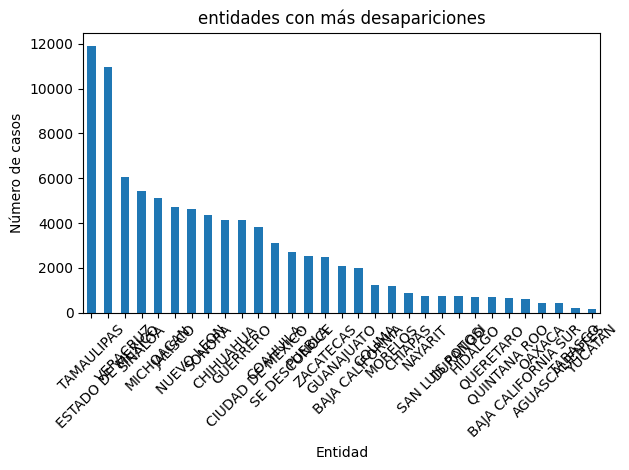

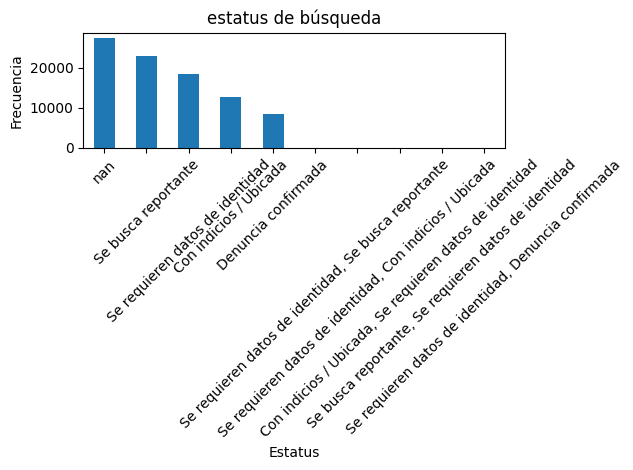

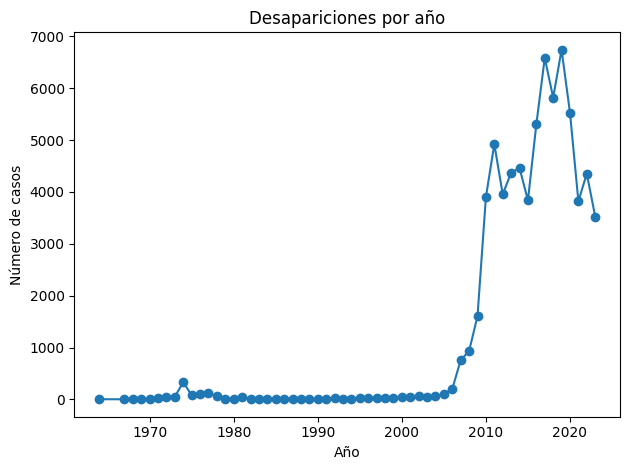

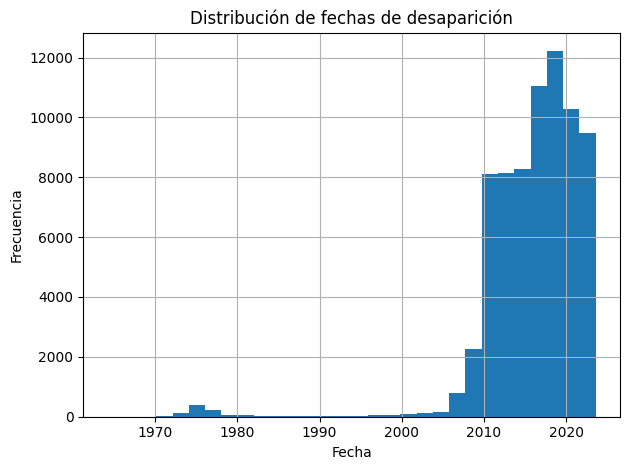

In [6]:
# =========================
# DISTRIBUCIÓN: entidad_desap
# =========================
top_entidades = df["entidad_desap"].value_counts().head(31)

plt.figure()
top_entidades.plot(kind="bar")
plt.title("entidades con más desapariciones")
plt.xlabel("Entidad")
plt.ylabel("Número de casos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# DISTRIBUCIÓN: estatus_busqueda
# =========================
top_estatus = df["estatus_busqueda"].value_counts(dropna=False).head(10)

plt.figure()
top_estatus.plot(kind="bar")
plt.title("estatus de búsqueda")
plt.xlabel("Estatus")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# DISTRIBUCIÓN TEMPORAL
# =========================
df["anio"] = df["fecha_desap"].dt.year

conteo_anual = df["anio"].value_counts().sort_index()

plt.figure()
conteo_anual.plot(kind="line", marker="o")
plt.title("Desapariciones por año")
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.show()

# =========================
# HISTOGRAMA DE FECHAS
# =========================
plt.figure()
df["fecha_desap"].dropna().hist(bins=30)
plt.title("Distribución de fechas de desaparición")
plt.xlabel("Fecha")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [7]:
# =========================
# FUNCION DE VARIABILIDAD
# =========================
def medidas_variabilidad(serie, nombre):
    print("\n=========================")
    print(f"VARIABLE: {nombre}")
    print("=========================")

    # Eliminar nulos
    #serie = serie.dropna()

    # Si es fecha convertir a numérico (timestamp)
    if pd.api.types.is_datetime64_any_dtype(serie):
        serie = serie.astype("int64")  # nanosegundos

    # Solo aplicar a datos numéricos
    if pd.api.types.is_numeric_dtype(serie):

        if len(serie) == 0:
            print("Sin datos suficientes")
            return

        rango = serie.max() - serie.min()
        varianza = serie.var(ddof=1)  # muestral
        desviacion = serie.std(ddof=1)
        media = serie.mean()

        # Coeficiente de variación
        if media != 0:
            coef_var = desviacion / media
        else:
            coef_var = np.nan

        print(f"Rango: {rango}")
        print(f"Varianza muestral: {varianza}")
        print(f"Desviación estándar muestral: {desviacion}")
        print(f"Coeficiente de variación: {coef_var}")

    else:
        print("No aplica (variable no numérica)")

# =========================
# VARIABLES DE INTERÉS
# =========================

medidas_variabilidad(df["fecha_desap"], "fecha_desap")

# analizar el año
df["anio"] = df["fecha_desap"].dt.year
medidas_variabilidad(df["anio"], "anio")


# =========================
# AUTOMÁTICO
# =========================

print("\n\n=== ANALISIS AUTOMATICO ===")
for col in df.columns:
    medidas_variabilidad(df[col], col)


VARIABLE: fecha_desap
Rango: -9221680929654775808
Varianza muestral: 1.3391600472573407e+37
Desviación estándar muestral: 3.659453575682223e+18
Coeficiente de variación: -2.029296850397153

VARIABLE: anio
Rango: 59.0
Varianza muestral: 40.24258068339376
Desviación estándar muestral: 6.34370401921415
Coeficiente de variación: 0.0031474199155539324


=== ANALISIS AUTOMATICO ===

VARIABLE: Unnamed: 0
Rango: 89719
Varianza muestral: 670814010.0
Desviación estándar muestral: 25900.077413011724
Coeficiente de variación: 0.5773470517049905

VARIABLE: nombrecompleto
No aplica (variable no numérica)

VARIABLE: rnpdno_json
Rango: 1
Varianza muestral: 0.09661867045857551
Desviación estándar muestral: 0.31083543951514847
Coeficiente de variación: 0.3486106606827561

VARIABLE: entidad_desap
No aplica (variable no numérica)

VARIABLE: pre_rnped
Rango: 1
Varianza muestral: 0.014463689466428736
Desviación estándar muestral: 0.12026507999593537
Coeficiente de variación: 8.193001501317632

VARIABLE: rn

/var/folders/yq/5vgkt53s6sn4yz076nh0n66m0000gn/T/ipykernel_4091/296089168.py:23: RuntimeWarning: overflow encountered in scalar subtract
  rango = serie.max() - serie.min()
/var/folders/yq/5vgkt53s6sn4yz076nh0n66m0000gn/T/ipykernel_4091/296089168.py:23: RuntimeWarning: overflow encountered in scalar subtract
  rango = serie.max() - serie.min()
